## A notebook to learn how to code transformers by implementing them from scratch.

In [2]:
# Downloading Fashion Mnist
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from torch.nn import functional as F
import einops
from tqdm.notebook import tqdm
import torch.nn as nn

1. Download fashionMNIST dataset if not already downloaded. Split training and validation set.

60000 10000
torch.Size([1, 28, 28]) 9


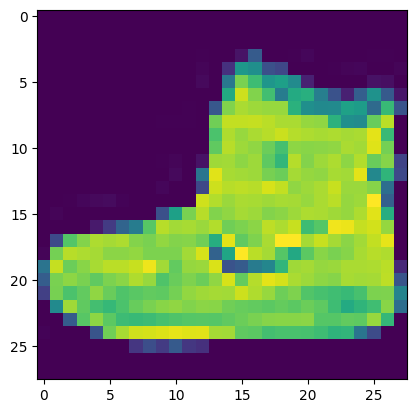

In [3]:
transform = transforms.ToTensor()

# Get data and store it in ./data folder
train_data = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
test_data = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

# Create dataloaders
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

# Show an example
print(len(train_data), len(test_data))
print(train_data[0][0].shape, train_data[0][1])
plt.imshow(train_data[0][0].squeeze().numpy())

## E1. Define Patchify and Un-Patchify functions

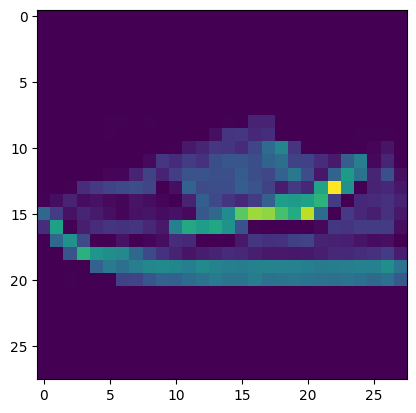

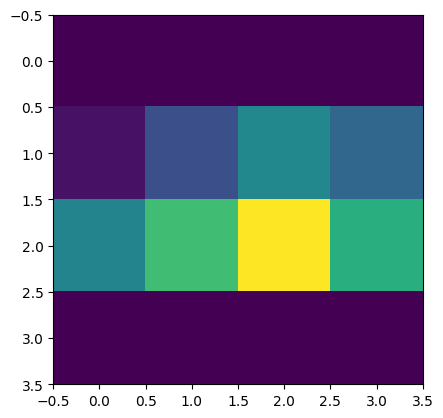

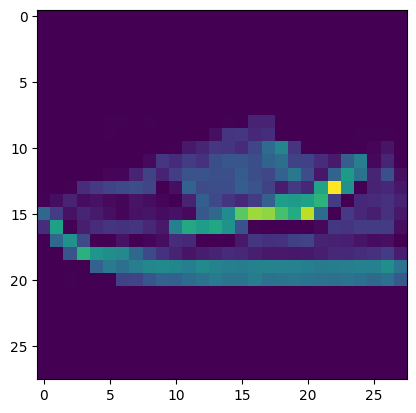

In [4]:
# --- FUNCTIONS --- 

def patchify(images: torch.Tensor, patch_size : int):
    """
    Patchifies images from (B, 1, 28, 28) to (B, 16, 49)
    
    Args:
        images: (B, C, H, W)
    """
    # Extract patches
    patches = F.unfold(images, kernel_size=patch_size, padding=0, stride=patch_size)
    # P are pixels inside a patch. G are patch grid position
    patches = einops.rearrange(patches, "... P G -> ... G P")
    return patches


def unpatchify(patches: torch.Tensor, patch_size : int, grid_size: int):
    """
    Unpatchify patches to the original image from (B, 16, 49) to (B, 1, 28, 28)
    
    Args:
        images: (B, 16, 49)
    """
    # Reshape patches. ph pw are pixels inside a patch. gh gw are patch grid position
    images = einops.rearrange(patches, "... (gh gw) (ph pw) -> ... 1 (gh ph) (gw pw)", gh=grid_size, ph=patch_size)
    
    return images

# --- TEST RUN ---

# Get image sample
images, labels = next(iter(train_loader))
patch_size = 7
grid_size = int(images[0].shape[-1] // patch_size)

# Patchify
patches = patchify(images, patch_size=patch_size)
# Unpatchify
unpatchified_images = unpatchify(patches, patch_size=patch_size, grid_size=grid_size)
# Check patchified and unpatchified images are the same
assert torch.allclose(unpatchified_images, images)   # must be EXACTLY identity

# plot actual image
plt.figure()
plt.imshow(images[0].squeeze().numpy())

# plot average of patches
plt.figure()
patch_grid = einops.rearrange(patches[0].mean(dim=-1), "(gh gw) -> gh gw", gh=grid_size)
plt.imshow(patch_grid)

# plot fully tiled patches
plt.figure()
patch_grid = einops.rearrange(patches[0], "(gh gw) (ph pw) -> (gh ph) (gw pw)", gh=grid_size, ph=patch_size)
plt.imshow(patch_grid)

    

## E2. Define Attention and a small ViT autoencoder from scratch

### E2.a. Multi-head Self-Attention

In [5]:
class MultiheadAttention(nn.Module):
    def __init__(self, dim: int, n_heads: int):
        super().__init__()
        self.head_dim = dim // n_heads
        self.n_heads = n_heads
        self.proj = nn.Linear(dim, 3 * self.head_dim * n_heads, bias=False)
        
        # The last layer that fuses multiple attention heads into a single layer
        self.to_out = nn.Linear(self.head_dim * n_heads, dim, bias=False)

        
    def forward(self, seq):
        """
        Args:
            seq (B, N, dim)
            
        Returns:
            out: (B, N, dim)
            attention: (B, n_heads, N, dim)
        """
        # project to Q, K and V
        qkv = self.proj(seq)
        q, k, v = qkv.chunk(3, dim=-1)
        
        # Rearrange to move head outside to perform attention calucation PER head
        q = einops.rearrange(q, " b n (h d) -> b h n d", h = self.n_heads)
        k = einops.rearrange(k, " b n (h d) -> b h n d", h = self.n_heads)
        v = einops.rearrange(v, " b n (h d) -> b h n d", h = self.n_heads)
        
        # Dot product of Queries and Keys
        score_matrix = einops.einsum(q, k, "... n1 d, ... n2 d -> ... n1 n2") # contracted dimension much share same var name in einops (here it is 'd')
        
        # scale by head size
        score_matrix = score_matrix / (self.head_dim**0.5)
        
        # Applying softmax to the score matrix
        attention = torch.softmax(score_matrix, dim=-1)
        
        # Weighting attention by the value
        attention = attention @ v
        
        # Move heads back to dim
        out = einops.rearrange(attention, "b h n d -> b n (h d)")
        
        # Fuse multi-heads int a linear layer
        out = self.to_out(out)
        
        return out, attention


x = torch.rand((3, 10, 512))
print(x.shape)

attn = MultiheadAttention(512, 5)
print(attn(x)[0].shape)

torch.Size([3, 10, 512])
torch.Size([3, 10, 512])


### E2.b. A pre-LN Transformer block

In [6]:
class AttnBlock(nn.Module):
    def __init__(self, dim: int, n_heads: int, attn_multiple: int = 4):
        super().__init__()
        self.attention = MultiheadAttention(dim, n_heads)
        self.layer_norm1 = nn.LayerNorm(dim)
        self.layer_norm2 = nn.LayerNorm(dim)
        self.ff = nn.Sequential(
            nn.Linear(dim, attn_multiple * dim),
            nn.GELU(),
            nn.Linear(attn_multiple * dim, dim)
        )        
                
    
    def forward(self, x):
        # attending to tokens across patches with a residual
        out, _ = self.attention(self.layer_norm1(x))
        x = x + out
        
        # channel mixing per token - a "scratch space" to make sense of the tokens we attended to
        out = self.ff(self.layer_norm2(x))
        x = x + out
        
        return x
        
x = torch.rand((3, 10, 512))
print(x.shape)

attn_block = AttnBlock(512, 5)
print(attn_block(x).shape)

torch.Size([3, 10, 512])
torch.Size([3, 10, 512])


### E2.c. Assemble a ViT autoencoder

In [ ]:
class ViT_Encoder(nn.Module):
    def __init__(self, dim: int, n_heads: int, z_dim: int, P: int, N: int, k: int = 2, use_pos: bool = True):
        super().__init__()
        self.use_pos = use_pos
        self.ff = nn.Sequential(nn.Linear(P, dim), nn.GELU())
                
        # Stack attention blocks
        self.attn_blocks = nn.Sequential(*[AttnBlock(dim, n_heads) for i in range(k)])
        
        # Linear layer to encode to a lower dim (not sure if we should use GELU here or not)
        self.ff2 = nn.Sequential(nn.GELU(), nn.Linear(dim, z_dim))
                        
        # Layer for positional encoding
        self.pos = nn.Parameter(torch.randn(1, N, dim) * 0.02) # N = grid_size ** 2
        
        
    def forward(self, seq):
        """
        Args:
            seq (B, N, P) P is patch_size**2 and N is number of patches rows x coloumns
            
        Returns:
            z (B, N, z_dim)
        """
        # embed sequence
        x = self.ff(seq)   
        
        # positional encoding             
        if self.use_pos:
            x = x + self.pos
        
        # Attention block
        x = self.attn_blocks(x)
        
        # project sequence to comrpessed latent vector
        z = self.ff2(x)
        return z
    
    
class ViT_Decoder(nn.Module):
    def __init__(self, dim: int, n_heads: int, z_dim: int, P: int, k: int = 2):
        super().__init__()
        
        # Linear layer to decode from a lower dim to a higher one (not sure if we should use GELU here or not)
        self.ff = nn.Sequential(nn.GELU(), nn.Linear(z_dim, dim))
        
        # Stack attention blocks
        self.attn_blocks = nn.Sequential(*[AttnBlock(dim, n_heads) for i in range(k)])
        
        # Linear layer to unembed tokens. Linear shouldn't end with an activation function since we want raw pixel values (basic ML stuff)
        self.ff2 = nn.Sequential(nn.GELU(), nn.Linear(dim, P))

    def forward(self, seq):
        """
        Args:
            seq (B, N, z_dim): latent vector encoded via ViT_Encoder
            
        Returns:
            out (B, N, P) P is patch_size**2 and N is number of patches rows x coloumns
        """
        x = self.ff(seq)
        x = self.attn_blocks(x)
        x = self.ff2(x)
        return x


class ViT_AutoEncoder(nn.Module):
    def __init__(self, dim: int, n_heads: int, z_dim: int, patch_size: int, grid_size: int, k: int = 2, use_pos=True):
        super().__init__()
        
        self.patch_size = patch_size
        self.grid_size = grid_size
        
        self.encoder = ViT_Encoder(dim, n_heads, z_dim, patch_size**2, grid_size**2, k=k, use_pos=use_pos)
        self.decoder = ViT_Decoder(dim, n_heads, z_dim, patch_size**2, k)


    def forward(self, images):
        """
        Args:
            images (B, C, H, W)
        """
        image_patches = patchify(images, self.patch_size)
        z = self.encoder(image_patches)
        seq = self.decoder(z)
        recon = unpatchify(seq, self.patch_size, self.grid_size )
        
        return recon, z

    
    
# --- Training Loop ---
# define hyperparams
epochs = 3
dim = 512
n_heads = 8
z_dim = 64
patch_size = 7
grid_size = int(next(iter(train_loader))[0].shape[-1] // patch_size)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# define model
model = ViT_AutoEncoder(dim, n_heads, z_dim, patch_size, grid_size).to(device)
model_nopos = ViT_AutoEncoder(dim, n_heads, z_dim, patch_size, grid_size, use_pos=False).to(device)

# setup optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

# define tracking lists
loss_history = []

# training loop
for epoch in tqdm(range(epochs)):
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
    
    for images, labels in pbar:
        images = images.to(device)

        # 1. run forward pass through model
        recon, z = model(images)
        
        # 2. calculate loss
        loss = F.mse_loss(recon, images)
        
        # 3. backprop and update weights
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Show live loss
        pbar.set_postfix(loss=loss.item())
        
        # Track loss
        loss_history.append(loss.item())
        
        
                

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 1/3:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 2/3:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 3/3:   0%|          | 0/938 [00:00<?, ?it/s]

### E3.c. Plot after positional encoding

min loss =  0.006683548912405968
recon loss on shown training recon =  0.0025712279602885246
recon loss on training recon batch =  0.008649374358355999
recon loss on shown validation recon =  0.003259150544181466
recon loss on validation recon batch =  0.008481859229505062


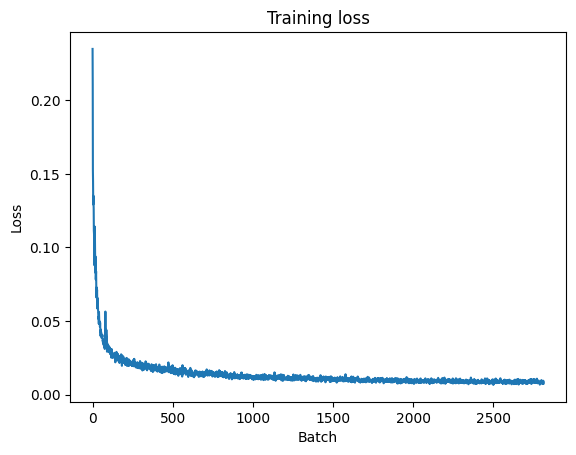

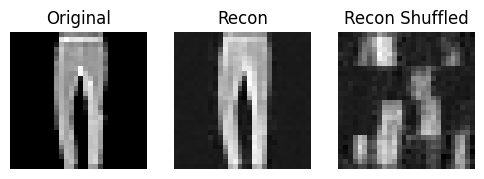

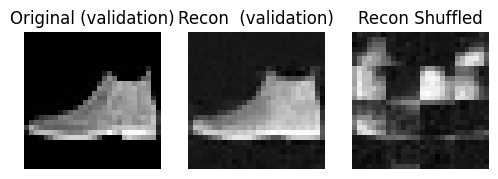

In [31]:
# Plot history loss
plt.figure()
plt.plot(loss_history)
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.title("Training loss")
print("min loss = ", min(loss_history))

# Plot a recon and compare to original
images, labels = next(iter(train_loader))
model.eval()
recons, _ = model(images.to(device))
print("recon loss on shown training recon = ", F.mse_loss(images[0].to(device), recons[0]).item())
print("recon loss on training recon batch = ", F.mse_loss(images.to(device), recons).item())

# Shuffle patches and run a forward pass through ViT model
perm = torch.randperm(model.grid_size**2)
image_patches = patchify(images.to(device), model.patch_size)
z = model.encoder(image_patches[:, perm])
seq = model.decoder(z)
recons_shuffled = unpatchify(seq, model.patch_size, model.grid_size )

# Plot a recon and compare to original
images_val, _ = next(iter(test_loader))
model.eval()
recons_val, _ = model(images_val.to(device))
print("recon loss on shown validation recon = ", F.mse_loss(images_val[0].to(device), recons_val[0]).item())
print("recon loss on validation recon batch = ", F.mse_loss(images_val.to(device), recons_val).item())

# Shuffle patches and run a forward pass through ViT model
perm = torch.randperm(model.grid_size**2)
image_patches = patchify(images_val.to(device), model.patch_size)
z = model.encoder(image_patches[:, perm])
seq = model.decoder(z)
recons_val_shuffled = unpatchify(seq, model.patch_size, model.grid_size )


fig, ax = plt.subplots(1, 3, figsize=(6, 3))
ax[0].imshow(images[0][0].cpu().numpy(), cmap="gray")
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(recons[0][0].detach().cpu().numpy(), cmap="gray")
ax[1].set_title("Recon")
ax[1].axis("off")

ax[2].imshow(recons_shuffled[0][0].detach().cpu().numpy(), cmap="gray")
ax[2].set_title("Recon Shuffled")
ax[2].axis("off")

plt.show()

fig, ax = plt.subplots(1, 3, figsize=(6, 3))
ax[0].imshow(images_val[0][0].cpu().numpy(), cmap="gray")
ax[0].set_title("Original (validation)")
ax[0].axis("off")

ax[1].imshow(recons_val[0][0].detach().cpu().numpy(), cmap="gray")
ax[1].set_title("Recon  (validation)")
ax[1].axis("off")


ax[2].imshow(recons_val_shuffled[0][0].detach().cpu().numpy(), cmap="gray")
ax[2].set_title("Recon Shuffled")
ax[2].axis("off")

plt.show()




### OLD plot before positional encoding

min loss =  0.002235807478427887
recon loss on shown training recon =  0.001833359943702817
recon loss on training recon batch =  0.002553098602220416
recon loss on shown validation recon =  0.0010779774747788906
recon loss on validation recon batch =  0.0026635886169970036


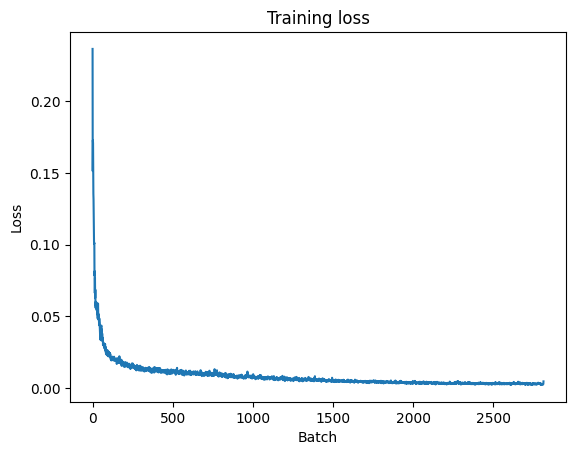

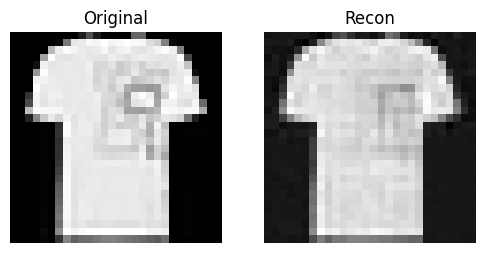

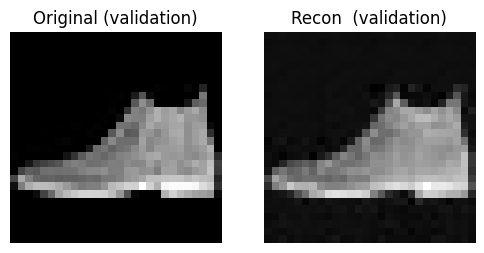

In [ ]:
# Plot history loss
plt.figure()
plt.plot(loss_history)
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.title("Training loss")
print("min loss = ", min(loss_history))

# Plot a recon and compare to original
images, labels = next(iter(train_loader))
model.eval()
recons = model(images.to(device))
print("recon loss on shown training recon = ", F.mse_loss(images[0].to(device), recons[0]).item())
print("recon loss on training recon batch = ", F.mse_loss(images.to(device), recons).item())

fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].imshow(images_val[0][0].cpu().numpy(), cmap="gray")
ax[0].set_title("Original (validation)")
ax[0].axis("off")

ax[1].imshow(recons_val[0][0].detach().cpu().numpy(), cmap="gray")
ax[1].set_title("Recon  (validation)")
ax[1].axis("off")

plt.show()




### E2.d. Check permutation Equivariance 

In [17]:
x, _ = next(iter(train_loader))
x = patchify(x.to(device), 7)
N = x.shape[1] 
perm = torch.randperm(N)
attn = MultiheadAttention(49, 8).to(device)

# attention(shuffle(x)) == shuffle(attention(x))
# That means multihead attention mechanism is permutation-equivariance without positioanl encoding.
# in other words, it can't tell which patch is top-left vs bottom-right 
out1,_ = attn(x)
out2,_ = attn(x[:, perm])
print(torch.allclose(out2, out1[:, perm], atol=1e-5))   # expect True


True


### E3.b. Check permutation equivariance for encoder with positional encoding

In [40]:
x, _ = next(iter(train_loader))
x = patchify(x.to(device), 7)
N = x.shape[1] 
perm = torch.randperm(N)
attn = MultiheadAttention(49, 8).to(device)
encoder = ViT_Encoder(dim, n_heads, z_dim, patch_size**2, grid_size**2, use_pos=True).to(device)

# attention(shuffle(x)) == shuffle(attention(x))
# That means multihead attention mechanism is permutation-equivariance without positioanl encoding.
# in other words, it can't tell which patch is top-left vs bottom-right 
out1 = encoder(x)
out2 = encoder(x[:, perm])
print(torch.allclose(out2, out1[:, perm], atol=1e-5))   # expect True

encoder = ViT_Encoder(dim, n_heads, z_dim, patch_size**2, grid_size**2, use_pos=False).to(device)

# attention(shuffle(x)) == shuffle(attention(x))
# That means multihead attention mechanism is permutation-equivariance without positioanl encoding.
# in other words, it can't tell which patch is top-left vs bottom-right 
out1 = encoder(x)
out2 = encoder(x[:, perm])
print(torch.allclose(out2, out1[:, perm], atol=1e-5))   # expect True



False
True


In [53]:
B, N, P = seq.shape
B

64

### E4. CLS token vs pooling

In [97]:
class ViT_EncoderCLS(nn.Module):
    def __init__(self, dim: int, n_heads: int, z_dim: int, P: int, N: int, k: int = 2, use_pos: bool = True):
        super().__init__()
        self.use_pos = use_pos
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim) * 0.02) # initialize cls token
        self.ff = nn.Sequential(nn.Linear(P, dim), nn.GELU())
                
        # Stack attention blocks
        self.attn_blocks = nn.Sequential(*[AttnBlock(dim, n_heads) for i in range(k)])
        
        # Linear layer to encode to a lower dim 
        self.ff2 = nn.Sequential(nn.GELU(), nn.Linear(dim, 10)) # 10 is number of classes of FashionMNIST
                        
        # Layer for positional encoding
        self.pos = nn.Parameter(torch.randn(1, N + 1, dim) * 0.02) # N = grid_size ** 2 (the +1 is the additional cls token)
        
        
    def forward(self, seq, out_type="cls", return_features=False):
        """
        Args:
            seq (B, N, P) P is patch_size**2 and N is number of patches rows x coloumns
            
        Returns:
            cls_token (B, dim)
        """
        B, N, P = seq.size()
        
        # embed sequence
        x = self.ff(seq)  
        
        # prepend cls token to embedded seq
        cls_token = self.cls_token.expand(B, -1, -1) # (B, 1, dim) expand don't repeat/copy        
        x = torch.cat([cls_token, x], dim=1) # shape becomes (B, N+1, dim)
         
        # positional encoding             
        if self.use_pos:
            x = x + self.pos
        
        # Attention block
        x = self.attn_blocks(x)
                 
        if out_type == "cls":            
            x = x[:, 0] # take only cls token that theoretically averages all other tokens (B, dim)
            
        elif out_type == "mean_pool":
            x = x[:, 1:].mean(dim=1) # mean pool averages all token to (B, dim)
            
        elif out_type == "max_pool":
            x = x[:, 1:].max(dim=1).values # takes max value (B, dim)
            
        if return_features:
            return x
            
        # # project sequence to comrpessed latent vector
        predicted_labels = self.ff2(x)
        
        return predicted_labels


# --- Training Loop ---
# define hyperparams
epochs = 3
dim = 512
n_heads = 8
z_dim = 64
patch_size = 7
grid_size = int(next(iter(train_loader))[0].shape[-1] // patch_size)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# define model
model_cls = ViT_EncoderCLS(dim, n_heads, z_dim, patch_size**2, grid_size**2).to(device)
model_mean = ViT_EncoderCLS(dim, n_heads, z_dim, patch_size**2, grid_size**2).to(device)
model_max = ViT_EncoderCLS(dim, n_heads, z_dim, patch_size**2, grid_size**2).to(device)

# setup optimizer
optimizer_cls = torch.optim.AdamW(model_cls.parameters(), lr=3e-4)
optimizer_mean = torch.optim.AdamW(model_mean.parameters(), lr=3e-4)
optimizer_max = torch.optim.AdamW(model_max.parameters(), lr=3e-4)

# define tracking lists
loss_history_cls = []
loss_history_mean = []
loss_history_max = []

# training loop
for epoch in tqdm(range(epochs)):
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
    
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)
        image_patches = patchify(images, patch_size=patch_size)

        # 1. run forward pass through model
        predicted_labels_cls = model_cls(image_patches, out_type="cls")
        predicted_labels_mean = model_mean(image_patches, out_type="mean_pool")
        predicted_labels_max = model_max(image_patches, out_type="max_pool")
        
        # 2. calculate loss
        loss_cls = F.cross_entropy(predicted_labels_cls, labels)
        loss_mean = F.cross_entropy(predicted_labels_mean, labels)
        loss_max = F.cross_entropy(predicted_labels_max, labels)
        
        # 3. backprop and update weights
        optimizer_cls.zero_grad(); loss_cls.backward(); optimizer_cls.step()
        optimizer_mean.zero_grad(); loss_mean.backward(); optimizer_mean.step()
        optimizer_max.zero_grad(); loss_max.backward(); optimizer_max.step()
        
        # Show live loss
        pbar.set_postfix(loss=loss_cls.item())
        
        # Track loss
        loss_history_cls.append(loss_cls.item())
        loss_history_mean.append(loss_mean.item())
        loss_history_max.append(loss_max.item())

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 1/3:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 2/3:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 3/3:   0%|          | 0/938 [00:00<?, ?it/s]

min loss cls =  0.11137163639068604
min loss mean =  0.08973647654056549
min loss max =  0.09212114661931992


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

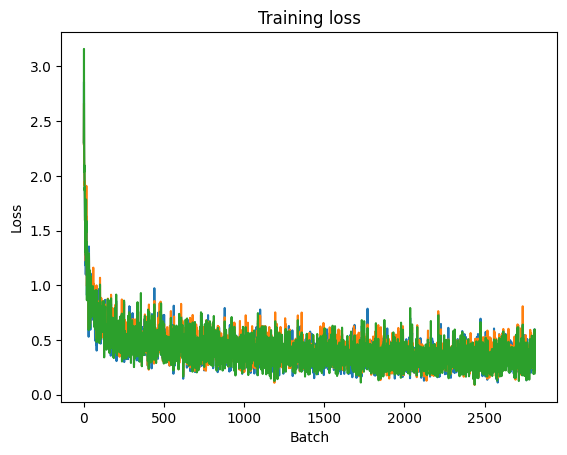

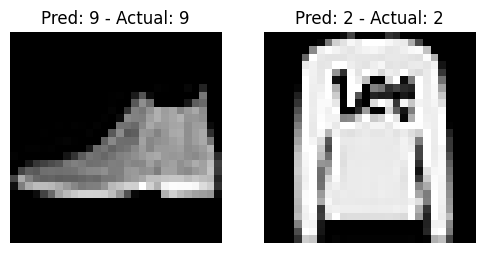

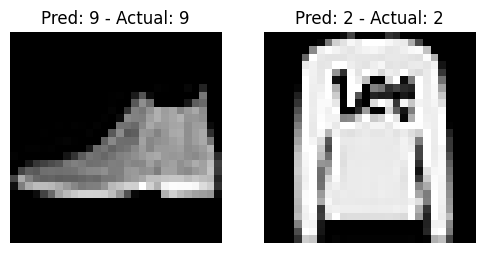

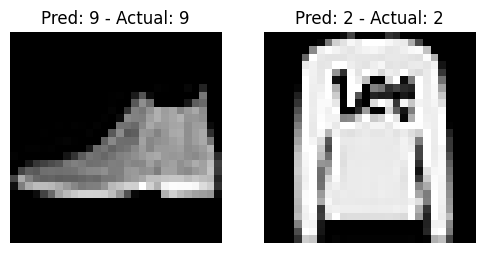

In [98]:
# Plot history loss
plt.figure()
plt.plot(loss_history_cls)
plt.plot(loss_history_mean)
plt.plot(loss_history_max)
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.title("Training loss")
print("min loss cls = ", min(loss_history_cls))
print("min loss mean = ", min(loss_history_mean))
print("min loss max = ", min(loss_history_max))

# Plot a recon and compare to original
images, labels = next(iter(test_loader))
image_patches = patchify(images.to(device), patch_size=patch_size)
model_cls.eval(); model_mean.eval(); model_max.eval(); 
predicted_labels_cls = model_cls(image_patches, out_type="cls")
predicted_labels_mean = model_mean(image_patches, out_type="mean_pool")
predicted_labels_max = model_max(image_patches, out_type="max_pool")

# plot predictiosn for model_cls
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].imshow(images[0][0].cpu().numpy(), cmap="gray")
ax[0].set_title(f"Pred: {predicted_labels_cls[0].argmax().item()} - Actual: {labels[0].item()}")
ax[0].axis("off")

ax[1].imshow(images[1][0].cpu().numpy(), cmap="gray")
ax[1].set_title(f"Pred: {predicted_labels_cls[1].argmax().item()} - Actual: {labels[1].item()}")
ax[1].axis("off")

# plot predictiosn for model_mean
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].imshow(images[0][0].cpu().numpy(), cmap="gray")
ax[0].set_title(f"Pred: {predicted_labels_mean[0].argmax().item()} - Actual: {labels[0].item()}")
ax[0].axis("off")

ax[1].imshow(images[1][0].cpu().numpy(), cmap="gray")
ax[1].set_title(f"Pred: {predicted_labels_mean[1].argmax().item()} - Actual: {labels[1].item()}")
ax[1].axis("off")

# plot predictiosn for model_max
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].imshow(images[0][0].cpu().numpy(), cmap="gray")
ax[0].set_title(f"Pred: {predicted_labels_max[0].argmax().item()} - Actual: {labels[0].item()}")
ax[0].axis("off")

ax[1].imshow(images[1][0].cpu().numpy(), cmap="gray")
ax[1].set_title(f"Pred: {predicted_labels_max[1].argmax().item()} - Actual: {labels[1].item()}")
ax[1].axis("off")


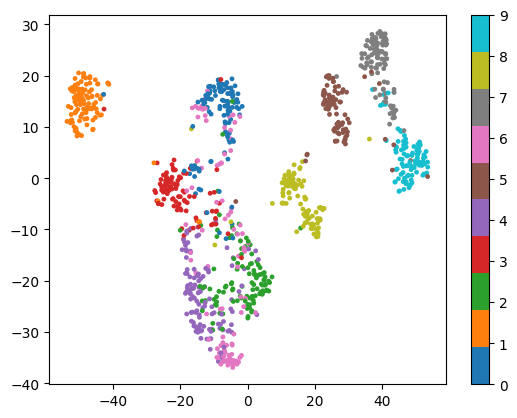

In [99]:
# plotting features of 1000 images in tsne plot
feats, labs = [], []
model_cls.eval()
with torch.no_grad():
    for imgs, lbls in test_loader:
        patches = patchify(imgs.to(device), patch_size)
        f = model_cls(patches, out_type="cls", return_features=True)   # (B, dim)
        feats.append(f.cpu()) 
        labs.append(lbls)
        if len(feats)*imgs.shape[0] >= 1000: break
feats = torch.cat(feats)[:1000].numpy()
labs  = torch.cat(labs)[:1000].numpy()

from sklearn.manifold import TSNE
emb = TSNE(n_components=2, perplexity=30, init="pca").fit_transform(feats)
plt.scatter(emb[:,0], emb[:,1], c=labs, cmap="tab10", s=6)
plt.colorbar()



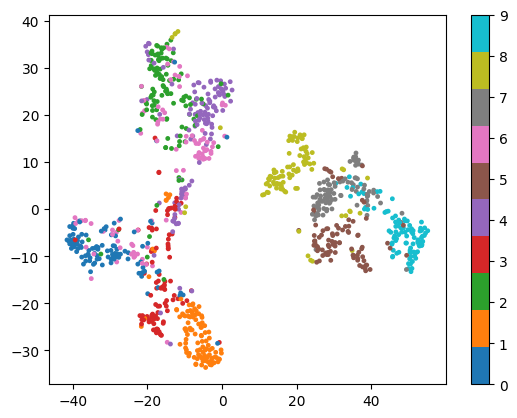

In [100]:
# plotting features of 1000 images in tsne plot
feats, labs = [], []
model_mean.eval()
with torch.no_grad():
    for imgs, lbls in test_loader:
        patches = patchify(imgs.to(device), patch_size)
        f = model_mean(patches, out_type="cls", return_features=True)   # (B, dim)
        feats.append(f.cpu()) 
        labs.append(lbls)
        if len(feats)*imgs.shape[0] >= 1000: break
feats = torch.cat(feats)[:1000].numpy()
labs  = torch.cat(labs)[:1000].numpy()

from sklearn.manifold import TSNE
emb = TSNE(n_components=2, perplexity=30, init="pca").fit_transform(feats)
plt.scatter(emb[:,0], emb[:,1], c=labs, cmap="tab10", s=6)
plt.colorbar()



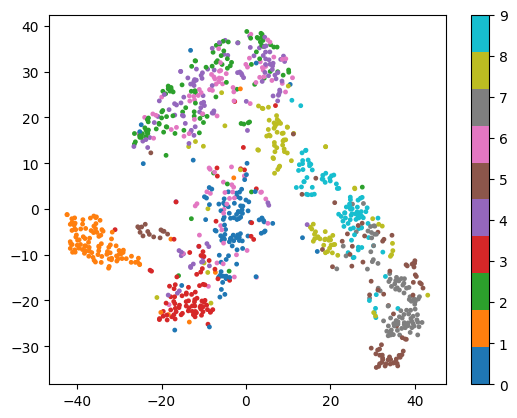

In [101]:
# plotting features of 1000 images in tsne plot
feats, labs = [], []
model_max.eval()
with torch.no_grad():
    for imgs, lbls in test_loader:
        patches = patchify(imgs.to(device), patch_size)
        f = model_max(patches, out_type="cls", return_features=True)   # (B, dim)
        feats.append(f.cpu()) 
        labs.append(lbls)
        if len(feats)*imgs.shape[0] >= 1000: break
feats = torch.cat(feats)[:1000].numpy()
labs  = torch.cat(labs)[:1000].numpy()

from sklearn.manifold import TSNE
emb = TSNE(n_components=2, perplexity=30, init="pca").fit_transform(feats)
plt.scatter(emb[:,0], emb[:,1], c=labs, cmap="tab10", s=6)
plt.colorbar()



### E5. Freezing ViT autoencoder to see if it makes better representation and classification than ViT encoder classifier


In [39]:
# define simple classifier
class Classifier(nn.Module):
    def __init__(self, z_dim):
        super().__init__()
        self.ff = nn.Sequential(nn.Linear(z_dim, 64), nn.Sigmoid(), nn.Linear(64, 10))
        
    def forward(self, x):
        # x = einops.rearrange(x, "... n z -> ... (n z)")
        
        x = self.ff(x)
        return x

classifier = Classifier(z_dim).to(device)
model.eval()

for p in model.parameters():
    p.requires_grad = False

# setup optimizer
optimizer = torch.optim.AdamW(classifier.parameters(), lr=3e-4)

# define tracking lists
loss_history = []

# training loop
for epoch in tqdm(range(epochs)):
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
    
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)

        # 1. run forward pass through model
        recon, z = model(images)
        predicted_labels = classifier(z)
        
        # 2. calculate loss
        loss = F.cross_entropy(predicted_labels, labels)
        
        # 3. backprop and update weights
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Show live loss
        pbar.set_postfix(loss=loss.item())
        
        # Track loss
        loss_history.append(loss.item())

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 1/3:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 2/3:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 3/3:   0%|          | 0/938 [00:00<?, ?it/s]

min loss =  0.46678417921066284


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

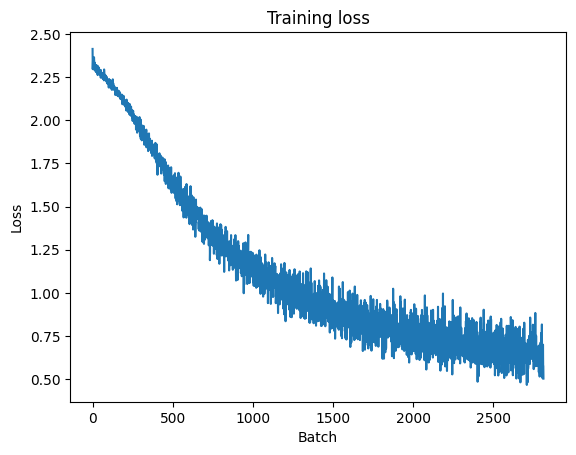

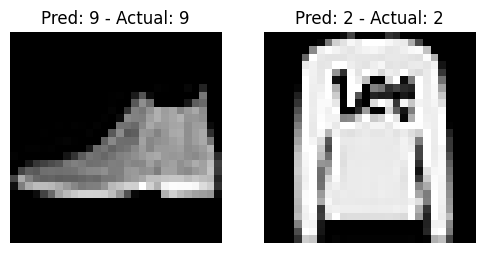

In [40]:
# Plot history loss
plt.figure()
plt.plot(loss_history)
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.title("Training loss")
print("min loss = ", min(loss_history))


# Plot a recon and compare to original
images, labels = next(iter(test_loader))
images = images.to(device)
classifier.eval()
recon, z = model(images)
predicted_labels = classifier(z)

# plot predictiosn for model_cls
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].imshow(images[0][0].cpu().numpy(), cmap="gray")
ax[0].set_title(f"Pred: {predicted_labels[0].argmax().item()} - Actual: {labels[0].item()}")
ax[0].axis("off")

ax[1].imshow(images[1][0].cpu().numpy(), cmap="gray")
ax[1].set_title(f"Pred: {predicted_labels[1].argmax().item()} - Actual: {labels[1].item()}")
ax[1].axis("off")




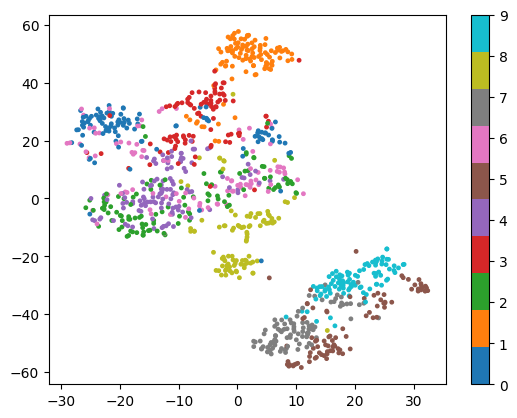

In [33]:
# plotting features of 1000 images in tsne plot
feats, labs = [], []
classifier.eval()
model.eval()
with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(device)
        _, f = model(imgs)
        # f = einops.rearrange(z, "... n z -> ... (n z)")
        # f = classifier(z)
        feats.append(f.cpu()) 
        labs.append(lbls)
        if len(feats)*imgs.shape[0] >= 1000: break
feats = torch.cat(feats)[:1000].numpy()
labs  = torch.cat(labs)[:1000].numpy()

from sklearn.manifold import TSNE
emb = TSNE(n_components=2, perplexity=30, init="pca").fit_transform(feats)
plt.scatter(emb[:,0], emb[:,1], c=labs, cmap="tab10", s=6)
plt.colorbar()
